# 03 — Naive Bayes

## Theory

Naive Bayes is a **generative, probabilistic** classifier built directly on
**Bayes' theorem**:

$$P(y \mid x) = \frac{P(x \mid y)\,P(y)}{P(x)}$$

To predict, we compare $P(y=1 \mid x)$ vs. $P(y=0 \mid x)$, and since
$P(x)$ is the same for both, we just need $P(x \mid y)\,P(y)$ for each
class. The hard part is $P(x \mid y)$ — the joint likelihood of *all*
features given the class — which is intractable to estimate directly for
more than a few features.

**The "naive" assumption** solves this by assuming every feature is
**conditionally independent** given the class:

$$P(x_1, \dots, x_n \mid y) = \prod_{i=1}^n P(x_i \mid y)$$

This is almost always false in the real world (`Credit amount` and
`Duration` move together, and the one-hot columns of a single original
variable are mutually exclusive by construction, as the correlation heatmap
in notebook 00 showed), yet Naive Bayes is frequently competitive in
practice — it needs
far fewer parameters to estimate, works well with limited data, and often
the *ranking* of class probabilities stays reasonable even when the
probabilities themselves are miscalibrated by the independence assumption.

We use **`GaussianNB`**, which assumes each continuous feature is
Normally distributed within each class:

$$P(x_i \mid y) = \frac{1}{\sqrt{2\pi\sigma_{y,i}^2}}\exp\!\left(-\frac{(x_i-\mu_{y,i})^2}{2\sigma_{y,i}^2}\right)$$

Training just means estimating $\mu_{y,i}$ and $\sigma_{y,i}^2$ (mean and
variance of feature `i` within class `y`) from the training data —
extremely fast, no iterative optimization needed. Because it works with
feature-wise means/variances rather than raw distances, GaussianNB doesn't
strictly require feature scaling (unlike KNN/SVM), though it doesn't hurt.

**A caveat specific to this dataset:** most of our 21 features are 0/1
one-hot columns, which are emphatically *not* Normally distributed — a
Bernoulli variable's mean and variance are tied together (`sigma^2 = p(1-p)`),
so fitting it with a free-floating Gaussian is a modelling error, not just
an approximation. `CategoricalNB` (or a mixed model that applies GaussianNB
to `Age`/`Credit amount`/`Duration` and CategoricalNB to the rest) would be
the textbook-correct choice. We stay with GaussianNB to keep the comparison
across notebooks on identical inputs — it still lands mid-pack — but the
mis-specification is worth keeping in mind when reading the numbers below.


In [4]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Harmless artifact of macOS's Accelerate BLAS backend on certain zero-valued
# matmul inputs (values stay finite and correct) -- not a real numerical issue.
warnings.filterwarnings("ignore", message=".*encountered in matmul.*", category=RuntimeWarning)

sns.set_theme(style="whitegrid")

DATA_PATH = "../data/german_credit_data.csv"

df = pd.read_csv(DATA_PATH, index_col=0)

# A blank in either account column means the applicant holds no such account
# -- real information, not a missing measurement -- so it becomes its own level.
df[["Saving accounts", "Checking account"]] = df[["Saving accounts", "Checking account"]].fillna("none")

# Binary target: 1 = "bad" credit risk, i.e. the borrower defaulted. See
# 00_data_exploration_and_preprocessing.ipynb for why "bad" is the positive
# class, why the blanks become "none", and how the categoricals are encoded.
y = (df["Risk"] == "bad").astype(int)

CATEGORICAL = ["Sex", "Housing", "Saving accounts", "Checking account", "Purpose"]
X = pd.get_dummies(df.drop(columns=["Risk"]), columns=CATEGORICAL, drop_first=True).astype(float)

# Same split (test_size, random_state, stratify) is used in every notebook
# in this folder so that results are directly comparable across algorithms.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print("Train class balance:")
print(y_train.value_counts(normalize=True).rename("proportion"))


Train shape: (800, 21), Test shape: (200, 21)
Train class balance:
Risk
0    0.7
1    0.3
Name: proportion, dtype: float64


In [5]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay,
)


def evaluate(model, X_te, y_te, y_pred=None, y_proba=None, label="model"):
    """Print the standard metric set and plot a confusion matrix."""
    if y_pred is None:
        y_pred = model.predict(X_te)
    print(f"--- {label} ---")
    print(classification_report(y_te, y_pred, target_names=["good risk", "bad risk"]))
    if y_proba is not None:
        print(f"ROC-AUC: {roc_auc_score(y_te, y_proba):.3f}")
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred, display_labels=["good", "bad"], cmap="Blues"
    )
    plt.title(f"Confusion matrix — {label}")
    plt.show()


--- Gaussian Naive Bayes (baseline) ---
              precision    recall  f1-score   support

   good risk       0.79      0.73      0.76       140
    bad risk       0.46      0.55      0.50        60

    accuracy                           0.68       200
   macro avg       0.63      0.64      0.63       200
weighted avg       0.69      0.68      0.68       200

ROC-AUC: 0.708


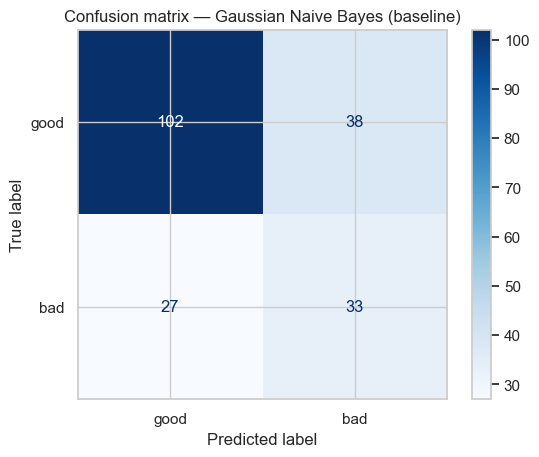

In [6]:
from sklearn.naive_bayes import GaussianNB

baseline = GaussianNB()
baseline.fit(X_train, y_train)

y_pred = baseline.predict(X_test)
y_proba = baseline.predict_proba(X_test)[:, 1]
evaluate(baseline, X_test, y_test, y_pred, y_proba, label="Gaussian Naive Bayes (baseline)")


## Regularization — `var_smoothing`

GaussianNB has a single, subtle hyperparameter: `var_smoothing`. It adds a
small fraction of the largest observed feature variance to *every* feature's
variance estimate:

$$\sigma_{y,i}^2 \leftarrow \sigma_{y,i}^2 + \text{var\_smoothing} \times \max_i(\sigma_i^2)$$

Without it, a feature that happens to have (near) zero variance within a
class would cause a division-by-near-zero in the Gaussian formula,
producing wildly overconfident (and unstable) probability estimates for any
new point that doesn't exactly match the training distribution. Increasing
`var_smoothing` is conceptually the same idea as **Laplace/additive
smoothing** used in `MultinomialNB`/`CategoricalNB` for discrete features:
in both cases we're injecting a bit of "we're not 100% sure" into the
likelihood estimate to avoid overfitting to the exact training sample,
trading a little bias for much more stable variance/probability estimates.


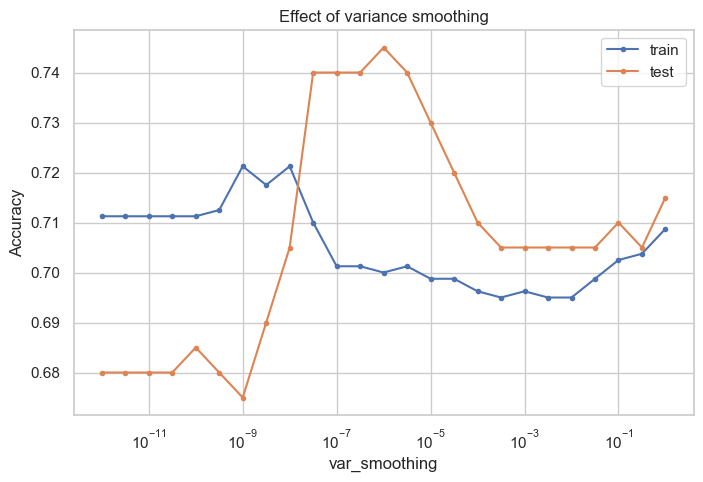

In [7]:
from sklearn.metrics import accuracy_score

smoothing_values = np.logspace(-12, 0, 25)
train_acc, test_acc = [], []

for vs in smoothing_values:
    nb = GaussianNB(var_smoothing=vs)
    nb.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, nb.predict(X_train)))
    test_acc.append(accuracy_score(y_test, nb.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(smoothing_values, train_acc, marker=".", label="train")
plt.plot(smoothing_values, test_acc, marker=".", label="test")
plt.xscale("log")
plt.xlabel("var_smoothing")
plt.ylabel("Accuracy")
plt.title("Effect of variance smoothing")
plt.legend()
plt.show()


## Hyperparameter search

Hyperparameters (`C`, `k`, `max_depth`, ...) are fixed before training, unlike
the weights the fit itself learns. All of them are selected here with **5-fold
cross-validation on the training set only**, scored on ROC-AUC: every
candidate setting is fit on four folds and scored on the fifth, rotating
through all five, and the averaged score decides the winner. The test set
takes no part in the search, which is what keeps the final numbers reported
after it meaningful.

`GridSearchCV` is used where the space is small enough to enumerate
exhaustively and `RandomizedSearchCV` where it is not — sampling a fixed
number of random combinations reaches a near-equivalent setting far more
cheaply once several hyperparameters turn out to barely move the score.


Best params: {'var_smoothing': np.float64(8.28642772854686e-09)}
Best CV ROC-AUC: 0.732
--- Gaussian Naive Bayes (tuned) ---
              precision    recall  f1-score   support

   good risk       0.78      0.80      0.79       140
    bad risk       0.51      0.48      0.50        60

    accuracy                           0.70       200
   macro avg       0.65      0.64      0.64       200
weighted avg       0.70      0.70      0.70       200

ROC-AUC: 0.734


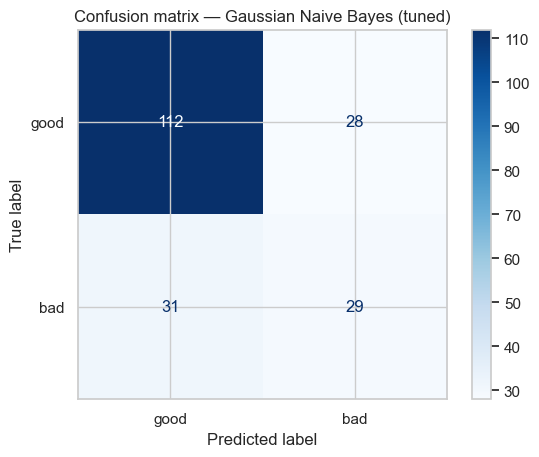

In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {"var_smoothing": np.logspace(-12, 0, 50)}

grid = GridSearchCV(GaussianNB(), param_grid=param_grid, scoring="roc_auc", cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print(f"Best CV ROC-AUC: {grid.best_score_:.3f}")

best_nb = grid.best_estimator_
y_pred = best_nb.predict(X_test)
y_proba = best_nb.predict_proba(X_test)[:, 1]
evaluate(best_nb, X_test, y_test, y_pred, y_proba, label="Gaussian Naive Bayes (tuned)")


## Decision threshold tuning

Every model in this project exposes a predicted probability `P(bad | x)` as
well as a hard label. `.predict()` converts one into the other at a fixed
cutoff of **0.5**: `P(bad) >= 0.5` becomes "bad risk".

0.5 is a library default, not a decision that belongs to this problem, and
two things make it the wrong cutoff here:

1. **Class imbalance.** Only ~30% of these applicants defaulted, so the model
   has to be unusually confident before `P(bad)` clears 0.5. The default
   cutoff quietly favours the majority "good" class and suppresses recall on
   exactly the class a lender needs to catch. (`class_weight="balanced"` is
   the other lever for this and moves roughly the same boundary, but it
   requires retraining.)
2. **Asymmetric costs.** Approving a loan that defaults costs the outstanding
   principal; declining an applicant who would have repaid costs only the
   foregone interest. Those are not the same number, which makes the cutoff a
   business parameter rather than a technicality — and moving it walks the
   model along its existing ROC / precision-recall curve without retraining
   anything.

Two reference cutoffs are computed below:

- **Youden's J** (`J = TPR - FPR`) on the ROC curve — the cutoff that
  separates the classes best when both error types are weighted equally.
- **F1-optimal** on the precision-recall curve — the cutoff that balances
  precision and recall on the positive class, the more informative of the two
  curves under this much imbalance.

> **Methodology caveat — both cutoffs below are selected on the test set,
> which is test-set leakage.**
>
> The scan maximises J / F1 over the held-out data itself, so the test set has
> informed a modelling decision and the two tuned rows are optimistic: they
> are not a clean estimate of how that cutoff would generalise. The step is
> kept because what is being recorded is the *size* of the precision/recall
> shift a cutoff can produce, not the specific threshold value.
>
> This is not how the cutoff would be set in production. There it would be
> chosen on data the model is not being judged on — a separate validation
> fold, or out-of-fold predictions from cross-validation — and then settled in
> deployment: shadow-score live applications for some days or weeks, watch the
> realised default rate against the approval rate, and adjust the cutoff by
> trial and error until it sits where the business wants it. The threshold is
> an operational dial that gets revisited, not a number frozen at training
> time.


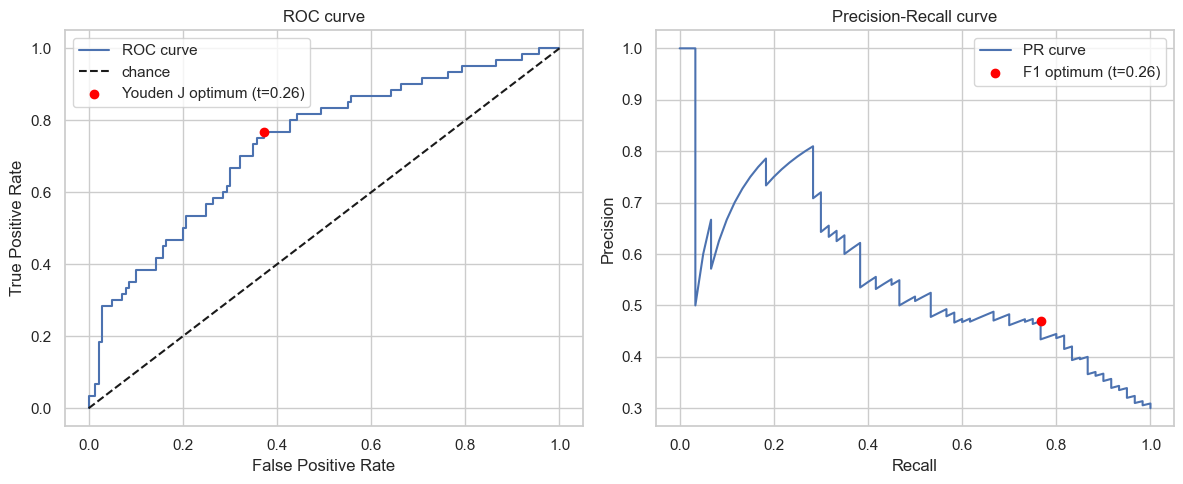

Youden's J optimal threshold: 0.257
F1-optimal threshold:         0.257


,threshold,accuracy,precision,recall,f1
default (0.5),0.500000,0.705,0.508772,0.483333,0.495726
Youden's J,0.256595,0.670,0.469388,0.766667,0.582278
F1-optimal,0.256595,0.670,0.469388,0.766667,0.582278


In [9]:
from sklearn.metrics import roc_curve, precision_recall_curve, f1_score

y_proba_best = best_nb.predict_proba(X_test)[:, 1]

# --- ROC curve & Youden's J statistic -------------------------------------
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba_best)
j_scores = tpr - fpr
best_j_idx = np.argmax(j_scores)
best_j_threshold = roc_thresholds[best_j_idx]

# --- Precision-Recall curve & F1-optimal threshold -------------------------
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba_best)
f1_scores = np.divide(
    2 * precision * recall, precision + recall,
    out=np.zeros_like(precision), where=(precision + recall) != 0
)
best_f1_idx = np.argmax(f1_scores[:-1])  # last point has no matching threshold
best_f1_threshold = pr_thresholds[best_f1_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, label="ROC curve")
axes[0].plot([0, 1], [0, 1], "k--", label="chance")
axes[0].scatter(fpr[best_j_idx], tpr[best_j_idx], color="red", zorder=5,
                 label=f"Youden J optimum (t={best_j_threshold:.2f})")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curve")
axes[0].legend()

axes[1].plot(recall, precision, label="PR curve")
axes[1].scatter(recall[best_f1_idx], precision[best_f1_idx], color="red", zorder=5,
                 label=f"F1 optimum (t={best_f1_threshold:.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Youden's J optimal threshold: {best_j_threshold:.3f}")
print(f"F1-optimal threshold:         {best_f1_threshold:.3f}")


def metrics_at_threshold(y_true, proba, threshold):
    preds = (proba >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
    }


results = pd.DataFrame([
    metrics_at_threshold(y_test, y_proba_best, 0.5),
    metrics_at_threshold(y_test, y_proba_best, best_j_threshold),
    metrics_at_threshold(y_test, y_proba_best, best_f1_threshold),
], index=["default (0.5)", "Youden's J", "F1-optimal"])

results


## Summary

- GaussianNB on one-hot features is mis-specified by construction (see the
  caveat in the theory section above) and still landed mid-pack: ROC-AUC
  **0.708** baseline, **0.734** tuned.
- Its baseline recall on defaulters, 0.55, is the highest any model in this
  project reaches at the default 0.5 cutoff, tied with XGBoost. The
  independence assumption produces badly calibrated but widely spread
  probabilities, so 0.5 happens to sit nearer a usable operating point here
  than it does elsewhere.
- `var_smoothing` is a numerical-stability knob, not a capacity control like
  `C` or `k`. The search picked 8.3e-9, essentially the 1e-9 default, and the
  gap between tuned and baseline test ROC-AUC is smaller than the noise a
  200-row test set can resolve.
- Training is effectively instantaneous next to every other model here, which
  is what makes it worth keeping as a first pass on a new dataset.
